In [4]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import torch.nn as nn 
from torch.optim import SGD
import time 

In [5]:
class Classification_Scratch:
    
    
    def __init__(self,input_size,output_size):
        self.input_size = input_size
        self.output_size = output_size 
        self.W = torch.randn(input_size,output_size,requires_grad=True)
        self.b = torch.randn(output_size,requires_grad=True)
        
        
    def forward(self,X):
        return X @ self.W + self.b 
    
    def softmax(self,X):
        
        logits = self.forward(X)
        logits = logits - logits.max(dim=1,keepdim=True).values
        probs = torch.exp(logits)/ torch.exp(logits).sum(dim=1,keepdim=True)
        return probs
        
    
    def loss_l2(self,y,y_pred):
        
        
        y_true = y_pred[torch.arange(y.shape[0]),y]
        cross_entropy = -(torch.log(y_true)).mean() + 0.01*(self.W**2).sum()
        return cross_entropy
    
    
    def optimize(self,X,y):
        
        y_pred = self.softmax(X)
        loss = self.loss_l2(y,y_pred)
        loss.backward()
        
        with torch.no_grad():
            
            self.W -= 0.01*self.W.grad
            self.b -= 0.01*self.b.grad
            
            self.W.grad.zero_()
            self.b.grad.zero_()
            
        
        return loss.item()

    def fit(self,X,y,lr=0.01,epochs=100):
        
        X = torch.tensor(X,dtype = torch.float32)
        y = torch.tensor(y,dtype = torch.long)
        
        dataset = TensorDataset(X,y)
        
        dataloader = DataLoader(dataset,batch_size=32,shuffle=True)
        
        
        for epoch in range(epochs):
            loss = 0 
            for batchX,batchy  in dataloader:
                batch_loss = self.optimize(batchX,batchy)
                loss += batch_loss 
            
            loss/=len(dataloader)
            
            print(f"Epoch {epoch+1}/{epochs}, loss : {loss}")
    def predict(self,X):
        X = torch.tensor(X,dtype=torch.float32)
        with torch.no_grad():
            probs = self.softmax(X)
            return torch.argmax(probs,dim=1)
            
            
            
class Classification_Torch:
    
    def __init__(self,input_size,output_size):
        
        self.input_size = input_size
        self.output_size = output_size 
        self.loss_function = torch.nn.CrossEntropyLoss()
        self.linear = torch.nn.Linear(input_size,output_size)
        self.optimizer = torch.optim.SGD(self.linear.parameters(),lr=0.01,weight_decay=0.01)
    
    
    def forward(self,X):
        return self.linear(X)
    
    def optimize(self,X,y):
        
        y_pred = self.forward(X)

        self.optimizer.zero_grad()
        loss = self.loss_function(y_pred,y)
        loss.backward()
        self.optimizer.step()
        return loss.item()
    
    
    def fit(self,X,y,lr=0.01,epochs=100):
        
        X = torch.tensor(X,dtype = torch.float32)
        y = torch.tensor(y,dtype = torch.long)
        
        dataset = TensorDataset(X,y)
        
        dataloader = DataLoader(dataset,batch_size=32,shuffle=True)
        
        
        for epoch in range(epochs):
            loss = 0 
            for batchX,batchy  in dataloader:
                batch_loss = self.optimize(batchX,batchy)
                loss += batch_loss 
            
            loss/=len(dataloader)
            
            print(f"Epoch {epoch+1}/{epochs}, loss : {loss}")
            
            
    def predict(self,X):
        X = torch.tensor(X,dtype=torch.float32)
        with torch.no_grad():
            probs = self.linear(X)
            return torch.argmax(probs,dim=1)
            
        
        
        



================ SCRATCH MODEL TRAINING ================

Epoch 1/20, loss : 2.1428163266181945
Epoch 2/20, loss : 1.093011578321457
Epoch 3/20, loss : 0.8944915509223939
Epoch 4/20, loss : 0.7831097412109375
Epoch 5/20, loss : 0.7046654484272004
Epoch 6/20, loss : 0.6468305642604828
Epoch 7/20, loss : 0.604142082452774
Epoch 8/20, loss : 0.57228631234169
Epoch 9/20, loss : 0.5483947978019714
Epoch 10/20, loss : 0.531939418554306
Epoch 11/20, loss : 0.5189857351779937
Epoch 12/20, loss : 0.508934607744217
Epoch 13/20, loss : 0.49990523934364317
Epoch 14/20, loss : 0.49294013559818267
Epoch 15/20, loss : 0.4862320394515991
Epoch 16/20, loss : 0.4804774084091187
Epoch 17/20, loss : 0.47544299173355103
Epoch 18/20, loss : 0.4700590283870697
Epoch 19/20, loss : 0.46573115086555483
Epoch 20/20, loss : 0.46111384439468384

================ TORCH MODEL TRAINING ================

Epoch 1/20, loss : 0.4824059183597565
Epoch 2/20, loss : 0.3905203803777695
Epoch 3/20, loss : 0.3768065561056137


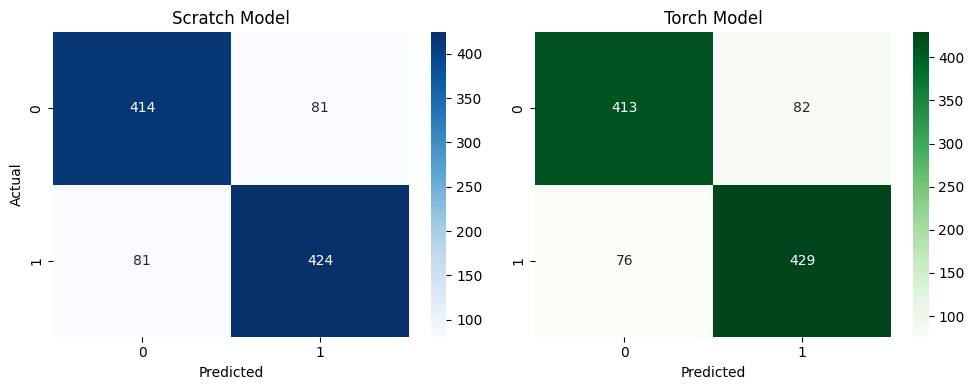

In [7]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# 1. CREATE DATASET
# -------------------------
X, y = make_classification(
    n_samples=5000,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    n_classes=2,
    random_state=42
)
input_size = X.shape[1]
output_size = len(set(y))

scratch_model = Classification_Scratch(input_size, output_size)
torch_model = Classification_Torch(input_size, output_size)

# -------------------------
# 2. TRAIN / TEST SPLIT
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\n================ SCRATCH MODEL TRAINING ================\n")
scratch_model.fit(X_train, y_train, epochs=20)

print("\n================ TORCH MODEL TRAINING ================\n")
torch_model.fit(X_train, y_train, epochs=20)


scratch_pred = scratch_model.predict(X_test)
scratch_pred = scratch_pred.numpy()

torch_pred = torch_model.predict(X_test)
torch_pred = torch_pred.numpy()

scratch_acc = accuracy_score(y_test, scratch_pred)
torch_acc = accuracy_score(y_test, torch_pred)

print("\n================ FINAL RESULTS ================\n")
print(f"Scratch Model Accuracy: {scratch_acc:.4f}")
print(f"Torch Model Accuracy:   {torch_acc:.4f}")

print("\n===== Scratch Model Report =====")
print(classification_report(y_test, scratch_pred))

print("\n===== Torch Model Report =====")
print(classification_report(y_test, torch_pred))


fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Scratch
cm1 = confusion_matrix(y_test, scratch_pred)
sns.heatmap(cm1, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Scratch Model")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Torch
cm2 = confusion_matrix(y_test, torch_pred)
sns.heatmap(cm2, annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("Torch Model")
axes[1].set_xlabel("Predicted")

plt.tight_layout()
plt.show()